In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np

# --------------- Setup ------------------
device = torch.device('mps' if torch.cuda.is_available() else 'cpu')

# --------------- VAE Definition ------------------

class VAE(nn.Module):
    def __init__(self, latent_dim=20):
        super(VAE, self).__init__()
        
        # Encoder
        self.encoder = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28*28, 400),
            nn.ReLU(),
            nn.Dropout(0.2),  # dropout for MC Dropout
        )
        self.fc_mu = nn.Linear(400, latent_dim)
        self.fc_logvar = nn.Linear(400, latent_dim)
        
        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 400),
            nn.ReLU(),
            nn.Dropout(0.2),  # dropout for MC Dropout
            nn.Linear(400, 28*28),
            nn.Sigmoid(),  # normalize output between 0 and 1
        )
    
    def encode(self, x):
        h = self.encoder(x)
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar
    
    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std
    
    def decode(self, z):
        return self.decoder(z)
    
    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        x_recon = self.decode(z)
        return x_recon, mu, logvar

# --------------- Loss Function ------------------

def vae_loss(x_recon, x, mu, logvar):
    recon_loss = nn.functional.binary_cross_entropy(x_recon, x.view(-1, 28*28), reduction='sum')
    kl_divergence = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return recon_loss + kl_divergence



In [2]:
# --------------- Load Data ------------------

transform = transforms.ToTensor()
train_dataset = datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=True)

# --------------- Training ------------------

vae = VAE(latent_dim=20).to(device)
optimizer = optim.Adam(vae.parameters(), lr=1e-3)
epochs = 30

vae.train()
for epoch in range(epochs):
    train_loss = 0
    for batch_idx, (data, _) in enumerate(train_loader):
        data = data.to(device)
        optimizer.zero_grad()
        x_recon, mu, logvar = vae(data)
        loss = vae_loss(x_recon, data, mu, logvar)
        loss.backward()
        train_loss += loss.item()
        optimizer.step()
    print(f"Epoch [{epoch+1}/{epochs}], Loss: {train_loss / len(train_loader.dataset):.4f}")

Epoch [1/30], Loss: 292.6415
Epoch [2/30], Loss: 263.5567
Epoch [3/30], Loss: 257.8885
Epoch [4/30], Loss: 254.9312
Epoch [5/30], Loss: 253.2266
Epoch [6/30], Loss: 252.1294
Epoch [7/30], Loss: 251.3083
Epoch [8/30], Loss: 250.7314
Epoch [9/30], Loss: 250.2580
Epoch [10/30], Loss: 249.8576
Epoch [11/30], Loss: 249.5387
Epoch [12/30], Loss: 249.1790
Epoch [13/30], Loss: 249.0466
Epoch [14/30], Loss: 248.7989
Epoch [15/30], Loss: 248.5865
Epoch [16/30], Loss: 248.3934
Epoch [17/30], Loss: 248.3710
Epoch [18/30], Loss: 248.0928
Epoch [19/30], Loss: 248.0298
Epoch [20/30], Loss: 247.8820
Epoch [21/30], Loss: 247.8396
Epoch [22/30], Loss: 247.6287
Epoch [23/30], Loss: 247.6080
Epoch [24/30], Loss: 247.5564
Epoch [25/30], Loss: 247.4871
Epoch [26/30], Loss: 247.2941
Epoch [27/30], Loss: 247.3212
Epoch [28/30], Loss: 247.2755
Epoch [29/30], Loss: 247.2016
Epoch [30/30], Loss: 247.1959


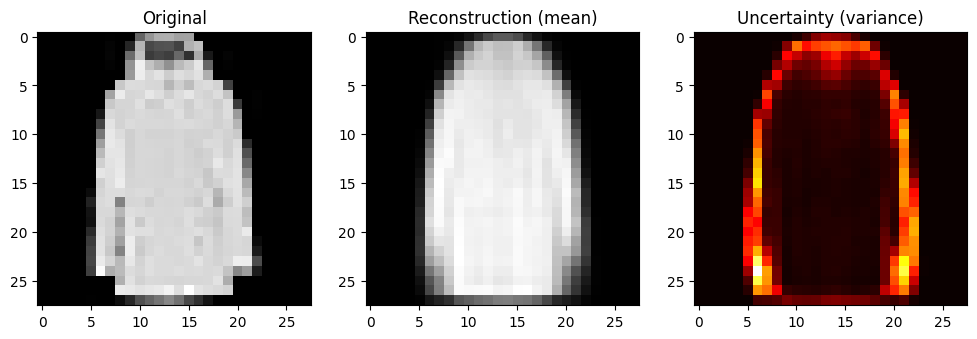

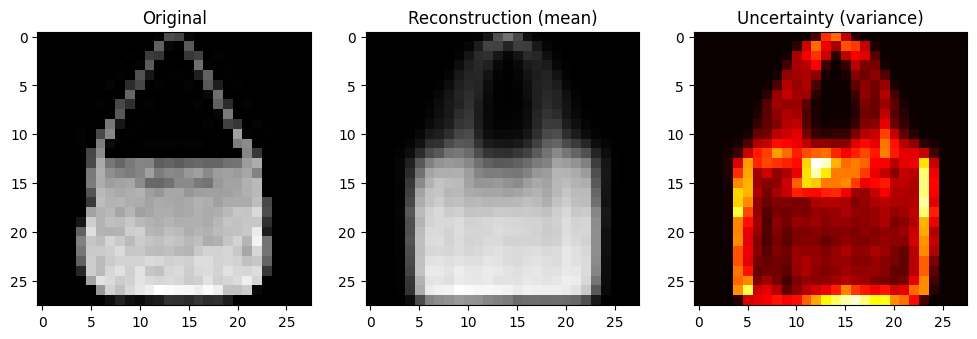

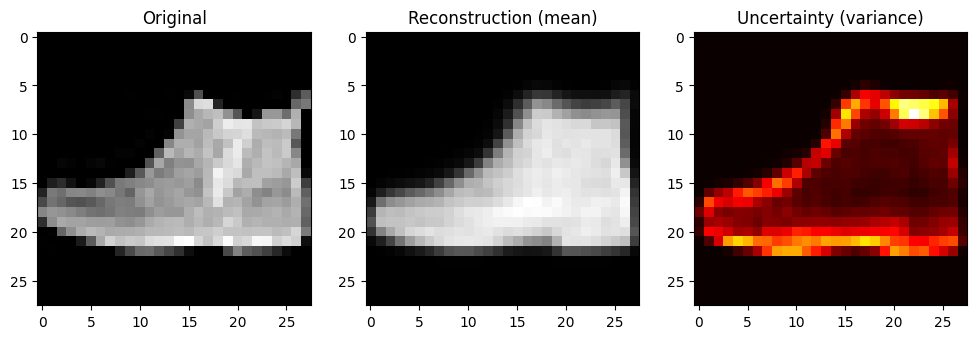

In [3]:
# --------------- MC Dropout Inference ------------------

def mc_dropout_predict(model, x, num_samples=30):
    model.train()  # Enable dropout at inference
    preds = []
    for _ in range(num_samples):
        with torch.no_grad():
            x_recon, _, _ = model(x)
            preds.append(x_recon.cpu().numpy())
    preds = np.stack(preds)  # Shape: [num_samples, batch_size=1, 28*28]
    mean_pred = preds.mean(axis=0)
    uncertainty = preds.var(axis=0)  # Variance as uncertainty
    return mean_pred, uncertainty

# --------------- Example Visualization ------------------

vae.eval()

examples = []
for batch_idx, (data, _) in enumerate(test_loader):
    data = data.to(device)
    mean_recon, uncertainty = mc_dropout_predict(vae, data, num_samples=30)
    
    original = data.cpu().squeeze().numpy()
    recon = mean_recon.squeeze()
    uncertainty = uncertainty.squeeze()
    
    fig, axs = plt.subplots(1, 3, figsize=(12, 4))

    axs[0].imshow(original, cmap='gray')
    axs[0].set_title('Original')

    axs[1].imshow(recon.reshape(28, 28), cmap='gray')
    axs[1].set_title('Reconstruction (mean)')

    axs[2].imshow(uncertainty.reshape(28, 28), cmap='hot')
    axs[2].set_title('Uncertainty (variance)')

    plt.show()

    
    if batch_idx == 2:  # Just show 3 examples
        break


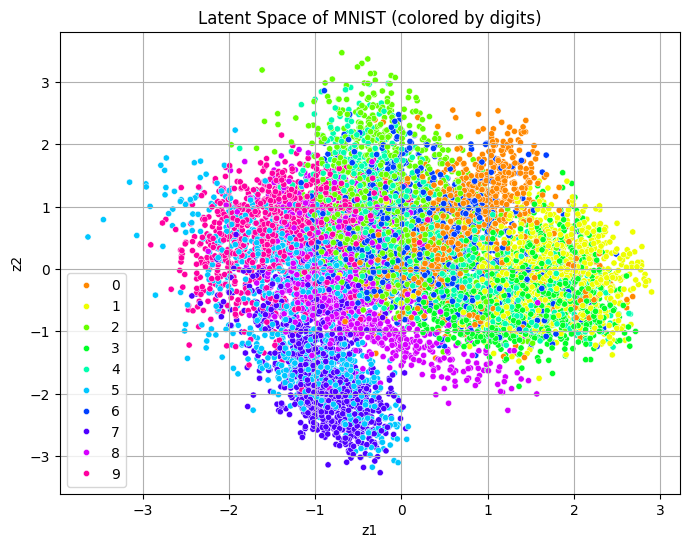

In [4]:
import seaborn as sns

vae.eval()

all_mu = []
all_labels = []

# Encode the entire test set
with torch.no_grad():
    for data, labels in test_loader:
        data = data.to(device)
        mu, logvar = vae.encode(data)
        all_mu.append(mu.cpu().numpy())
        all_labels.append(labels.numpy())

# Stack them together
all_mu = np.concatenate(all_mu, axis=0)
all_labels = np.concatenate(all_labels, axis=0)

# If latent dimension > 2, apply PCA to reduce to 2D
from sklearn.decomposition import PCA

if all_mu.shape[1] > 2:
    pca = PCA(n_components=2)
    z_2d = pca.fit_transform(all_mu)
else:
    z_2d = all_mu

# Plot
plt.figure(figsize=(8, 6))
palette = sns.color_palette("hsv", 10)  # 10 colors for 10 digits
sns.scatterplot(x=z_2d[:,0], y=z_2d[:,1], hue=all_labels, palette=palette, legend="full", s=20)
plt.title("Latent Space of MNIST (colored by digits)")
plt.xlabel("z1")
plt.ylabel("z2")
plt.grid(True)
plt.show()


In [28]:
# import torch
# import torch.nn as nn
# import torch.optim as optim
# from torch.utils.data import DataLoader
# from torchvision import datasets, transforms
# import matplotlib.pyplot as plt
# import numpy as np
# import seaborn as sns
# from sklearn.decomposition import PCA

# # --------------- Setup ------------------
# device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# # --------------- VAE Definition ------------------

# class VAE(nn.Module):
#     def __init__(self, latent_dim=2, dropout_rate=0.5):
#         super(VAE, self).__init__()
        
#         self.encoder = nn.Sequential(
#             nn.Flatten(),
#             nn.Linear(28*28, 400),
#             nn.ReLU(),
#             nn.Dropout(dropout_rate)  # <--- ADD DROPOUT HERE
#         )
#         self.fc_mu = nn.Linear(400, latent_dim)
#         self.fc_logvar = nn.Linear(400, latent_dim)
        
#         self.decoder = nn.Sequential(
#             nn.Linear(latent_dim, 400),
#             nn.ReLU(),
#             nn.Dropout(dropout_rate),  # <--- ADD DROPOUT HERE
#             nn.Linear(400, 28*28),
#             nn.Sigmoid()
#         )
    
#     def encode(self, x):
#         h = self.encoder(x)
#         mu = self.fc_mu(h)
#         logvar = self.fc_logvar(h)
#         return mu, logvar
    
#     def reparameterize(self, mu, logvar):
#         std = torch.exp(0.5 * logvar)
#         eps = torch.randn_like(std)
#         return mu + eps * std
    
#     def decode(self, z):
#         return self.decoder(z)
    
#     def forward(self, x):
#         mu, logvar = self.encode(x)
#         z = self.reparameterize(mu, logvar)
#         x_recon = self.decode(z)
#         return x_recon, mu, logvar


# # --------------- Loss Function ------------------

# def compute_loss(x_recon, x, mu, logvar, mode='both'):
#     recon_loss = nn.functional.binary_cross_entropy(x_recon, x.view(-1, 28*28), reduction='sum')
#     kl_div = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    
#     if mode == 'recon':
#         return recon_loss
#     elif mode == 'kl':
#         return kl_div
#     else:
#         return recon_loss + kl_div

# # --------------- Load Data ------------------

# transform = transforms.ToTensor()
# train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
# test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

# train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
# test_loader = DataLoader(test_dataset, batch_size=1024, shuffle=False)  # Larger batch for visualization

Mode: recon, Epoch [1/15], Loss: 287.4075
Mode: recon, Epoch [2/15], Loss: 268.9558
Mode: recon, Epoch [3/15], Loss: 266.9261
Mode: recon, Epoch [4/15], Loss: 265.7761
Mode: recon, Epoch [5/15], Loss: 264.9881
Mode: recon, Epoch [6/15], Loss: 264.4137
Mode: recon, Epoch [7/15], Loss: 263.9661
Mode: recon, Epoch [8/15], Loss: 263.5139
Mode: recon, Epoch [9/15], Loss: 263.0530
Mode: recon, Epoch [10/15], Loss: 262.7031
Mode: recon, Epoch [11/15], Loss: 262.4591
Mode: recon, Epoch [12/15], Loss: 262.1746
Mode: recon, Epoch [13/15], Loss: 262.0151
Mode: recon, Epoch [14/15], Loss: 261.8011
Mode: recon, Epoch [15/15], Loss: 261.5487
Mode: kl, Epoch [1/15], Loss: 0.0016
Mode: kl, Epoch [2/15], Loss: 0.0000
Mode: kl, Epoch [3/15], Loss: 0.0000
Mode: kl, Epoch [4/15], Loss: 0.0000
Mode: kl, Epoch [5/15], Loss: 0.0000
Mode: kl, Epoch [6/15], Loss: 0.0000
Mode: kl, Epoch [7/15], Loss: 0.0000
Mode: kl, Epoch [8/15], Loss: 0.0000
Mode: kl, Epoch [9/15], Loss: 0.0000
Mode: kl, Epoch [10/15], Loss: 

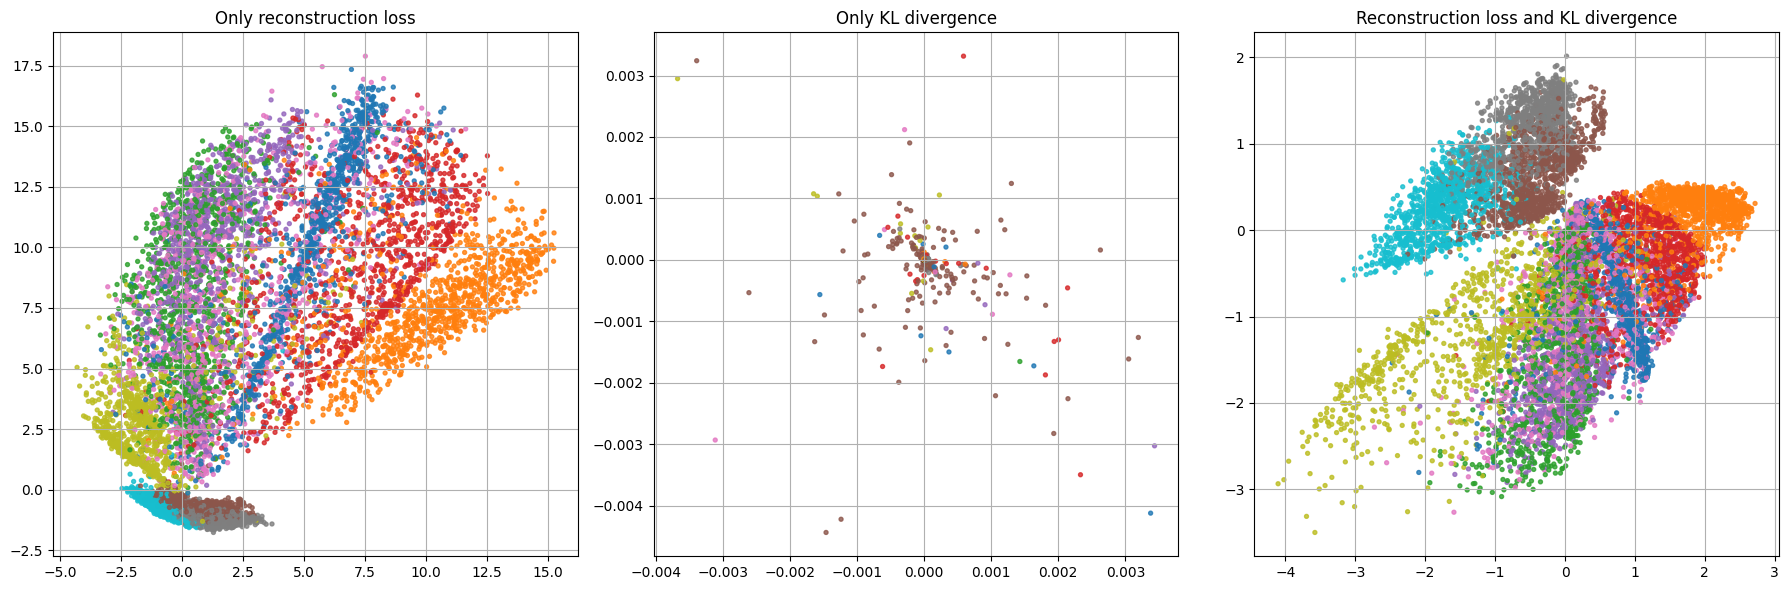

In [7]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.decomposition import PCA

# ---------------- Setup -------------------
device = torch.device('mps' if torch.cuda.is_available() else 'cpu')

# ---------------- VAE Definition -------------------

class VAE(nn.Module):
    def __init__(self, latent_dim=2):
        super(VAE, self).__init__()
        self.encoder = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28*28, 400),
            nn.ReLU(),
            nn.Dropout(0.2),
        )
        self.fc_mu = nn.Linear(400, latent_dim)
        self.fc_logvar = nn.Linear(400, latent_dim)
        
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 400),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(400, 28*28),
            nn.Sigmoid()
        )
    
    def encode(self, x):
        h = self.encoder(x)
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar
    
    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std
    
    def decode(self, z):
        return self.decoder(z)
    
    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        x_recon = self.decode(z)
        return x_recon, mu, logvar

# ---------------- Loss Function -------------------

def compute_loss(x_recon, x, mu, logvar, mode='both'):
    recon_loss = nn.functional.binary_cross_entropy(x_recon, x.view(-1, 28*28), reduction='sum')
    kl_div = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    
    if mode == 'recon':
        return recon_loss
    elif mode == 'kl':
        return kl_div
    else:
        return recon_loss + kl_div

# ---------------- Load Data -------------------

transform = transforms.ToTensor()
train_dataset = datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=1024, shuffle=False)

# ---------------- Training Function -------------------

def train_vae(mode='both'):
    vae = VAE(latent_dim=2).to(device)
    optimizer = optim.Adam(vae.parameters(), lr=1e-3)
    epochs = 15
    
    vae.train()
    for epoch in range(epochs):
        train_loss = 0
        for data, _ in train_loader:
            data = data.to(device)
            optimizer.zero_grad()
            x_recon, mu, logvar = vae(data)
            loss = compute_loss(x_recon, data, mu, logvar, mode=mode)
            loss.backward()
            train_loss += loss.item()
            optimizer.step()
        print(f"Mode: {mode}, Epoch [{epoch+1}/{epochs}], Loss: {train_loss / len(train_loader.dataset):.4f}")
    
    return vae

# ---------------- Get Latent Representations -------------------

def get_latent(vae):
    vae.eval()
    all_mu = []
    all_labels = []
    with torch.no_grad():
        for data, labels in test_loader:
            data = data.to(device)
            mu, logvar = vae.encode(data)
            all_mu.append(mu.cpu().numpy())
            all_labels.append(labels.numpy())
    all_mu = np.concatenate(all_mu, axis=0)
    all_labels = np.concatenate(all_labels, axis=0)
    return all_mu, all_labels

# ---------------- Train and Visualize -------------------

modes = ['recon', 'kl', 'both']
latent_spaces = []
labels_list = []

for mode in modes:
    vae = train_vae(mode=mode)
    mu, labels = get_latent(vae)
    latent_spaces.append(mu)
    labels_list.append(labels)

# ---------------- Plot -------------------

fig, axs = plt.subplots(1, 3, figsize=(18, 6))
titles = ['Only reconstruction loss', 'Only KL divergence', 'Reconstruction loss and KL divergence']

for i in range(3):
    z = latent_spaces[i]
    labels = labels_list[i]
    
    # If not already 2D, reduce to 2D
    if z.shape[1] > 2:
        pca = PCA(n_components=2)
        z = pca.fit_transform(z)
    
    axs[i].scatter(z[:,0], z[:,1], c=labels, cmap='tab10', s=8, alpha=0.8)
    axs[i].set_title(titles[i])
    axs[i].grid(True)

plt.tight_layout()
plt.show()

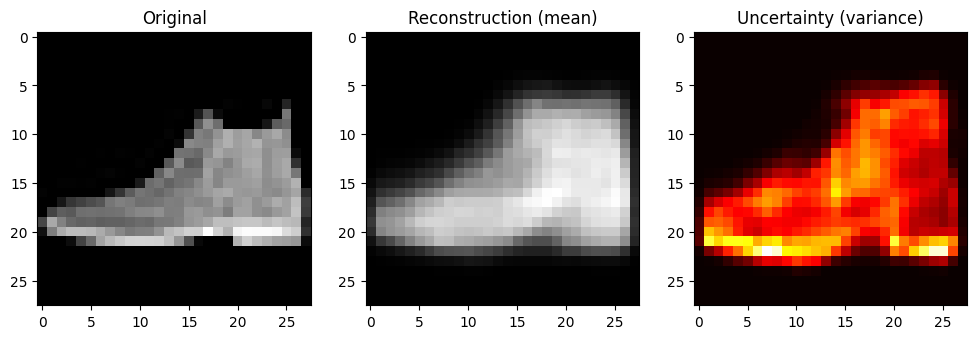

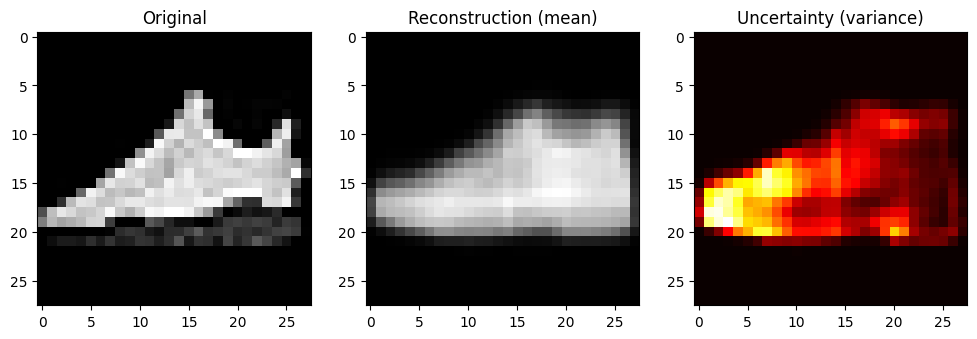

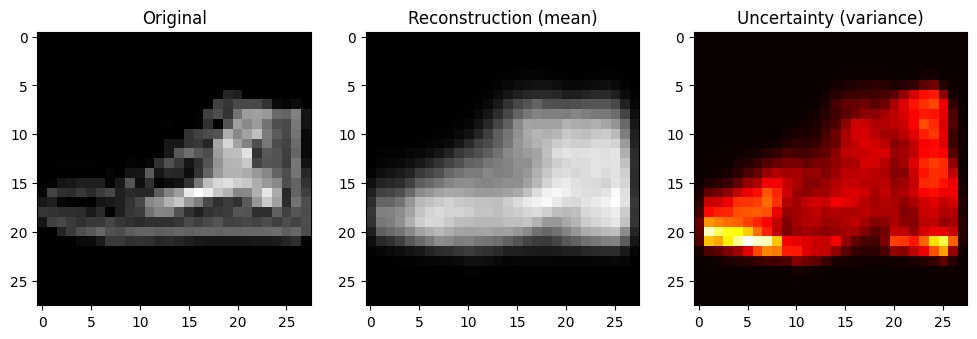

In [8]:
def mc_dropout_predict(model, x, num_samples=30):
    model.train()  # Enable dropout at inference
    preds = []
    for _ in range(num_samples):
        with torch.no_grad():
            x_recon, _, _ = model(x)
            preds.append(x_recon.cpu().numpy())
    preds = np.stack(preds)  # [num_samples, batch_size, 28*28]
    mean_pred = preds.mean(axis=0)    # Mean prediction over MC samples
    uncertainty = preds.var(axis=0)   # Variance = uncertainty
    return mean_pred, uncertainty


vae.eval()

for batch_idx, (data, _) in enumerate(test_loader):
    data = data.to(device)
    mean_recon, uncertainty = mc_dropout_predict(vae, data, num_samples=30)
    
    original = data[0].cpu().squeeze().numpy()         # Pick the first image in the batch
    recon = mean_recon[0].squeeze()
    uncertainty = uncertainty[0].squeeze()

    
    fig, axs = plt.subplots(1, 3, figsize=(12, 4))

    axs[0].imshow(original.reshape(28, 28), cmap='gray')
    axs[0].set_title('Original')

    axs[1].imshow(recon.reshape(28, 28), cmap='gray')
    axs[1].set_title('Reconstruction (mean)')

    axs[2].imshow(uncertainty.reshape(28, 28), cmap='hot')
    axs[2].set_title('Uncertainty (variance)')

    plt.show()

    if batch_idx == 2:  # Just show 3 examples
        break


In [33]:
# Load OOD dataset
ood_dataset = datasets.FashionMNIST(root='./data', train=False, download=True, transform=transforms.ToTensor())
ood_loader = DataLoader(ood_dataset, batch_size=128, shuffle=False)

In [34]:
def mc_dropout_predict(model, x, num_samples=30):
    model.train()  # Enable dropout at test time
    preds = []
    for _ in range(num_samples):
        with torch.no_grad():
            x_recon, _, _ = model(x)
            preds.append(x_recon.cpu().numpy())
    preds = np.stack(preds)
    mean_pred = preds.mean(axis=0)
    uncertainty = preds.var(axis=0)
    return mean_pred, uncertainty


In [35]:
def compute_average_uncertainty(model, dataloader):
    uncertainties = []
    for data, _ in dataloader:
        data = data.to(device)
        _, uncertainty = mc_dropout_predict(model, data, num_samples=30)
        batch_uncertainty = np.mean(uncertainty, axis=1)  # Average over pixel dimension (784)
        uncertainties.extend(batch_uncertainty)
    return uncertainties
mnist_uncertainties = compute_average_uncertainty(vae, test_loader)
fashion_uncertainties = compute_average_uncertainty(vae, ood_loader)

In [ ]:
def compute_reconstruction_error(model, dataloader):
    model.eval()
    errors = []
    for data, _ in dataloader:
        data = data.to(device)
        with torch.no_grad():
            x_recon, _, _ = model(data)
        batch_error = torch.mean((data.view(data.size(0), -1) - x_recon) ** 2, dim=1)  # MSE per image
        errors.extend(batch_error.cpu().numpy())
    return errors
mnist_errors = compute_reconstruction_error(vae, test_loader)
fashion_errors = compute_reconstruction_error(vae, ood_loader)


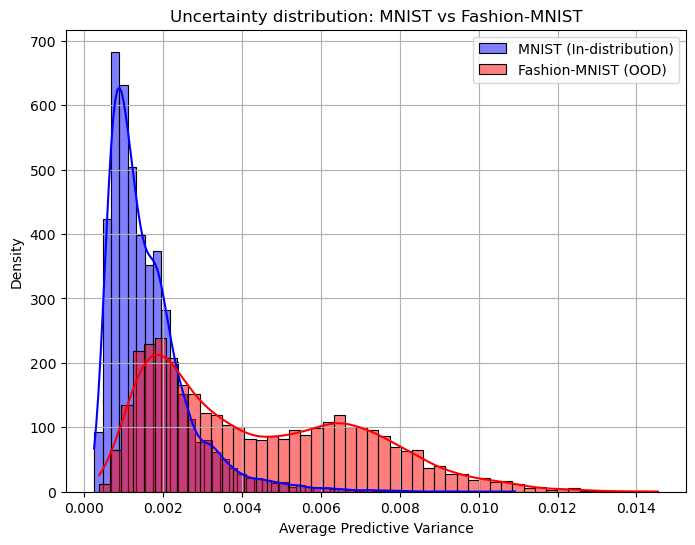

In [36]:
plt.figure(figsize=(8,6))
sns.histplot(mnist_uncertainties, color='blue', label='MNIST (In-distribution)', stat='density', bins=50, kde=True)
sns.histplot(fashion_uncertainties, color='red', label='Fashion-MNIST (OOD)', stat='density', bins=50, kde=True)
plt.legend()
plt.title('Uncertainty distribution: MNIST vs Fashion-MNIST')
plt.xlabel('Average Predictive Variance')
plt.ylabel('Density')
plt.grid(True)
plt.show()

In [37]:
from sklearn.metrics import roc_auc_score

# Labels: 0 = MNIST (in), 1 = FashionMNIST (OOD)
y_true = [0]*len(mnist_uncertainties) + [1]*len(fashion_uncertainties)
y_scores = mnist_uncertainties + fashion_uncertainties

auc = roc_auc_score(y_true, y_scores)
print(f"AUROC for OOD detection: {auc:.4f}")

AUROC for OOD detection: 0.8536


## VAE (Predictive Mean + Variance)

In [71]:
class VAE(nn.Module):
    def __init__(self, latent_dim=20):
        super(VAE, self).__init__()
        
        self.encoder = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28*28, 512),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(512, 256),
            nn.ReLU(),
        )
        self.fc_mu = nn.Linear(256, latent_dim)
        self.fc_logvar = nn.Linear(256, latent_dim)

        self.decoder_fc = nn.Sequential(
            nn.Linear(latent_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 512),
            nn.ReLU(),
        )

        self.decoder_mean = nn.Linear(512, 28*28)
        self.decoder_logvar = nn.Linear(512, 28*28)


    
    def encode(self, x):
        h = self.encoder(x)
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        h = self.decoder_fc(z)
        mean = torch.sigmoid(self.decoder_mean(h))   # [0,1] range
        logvar = self.decoder_logvar(h)               # No activation (can be positive or negative)
        return mean, logvar

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        mean, logvar_out = self.decode(z)
        return mean, logvar_out, mu, logvar


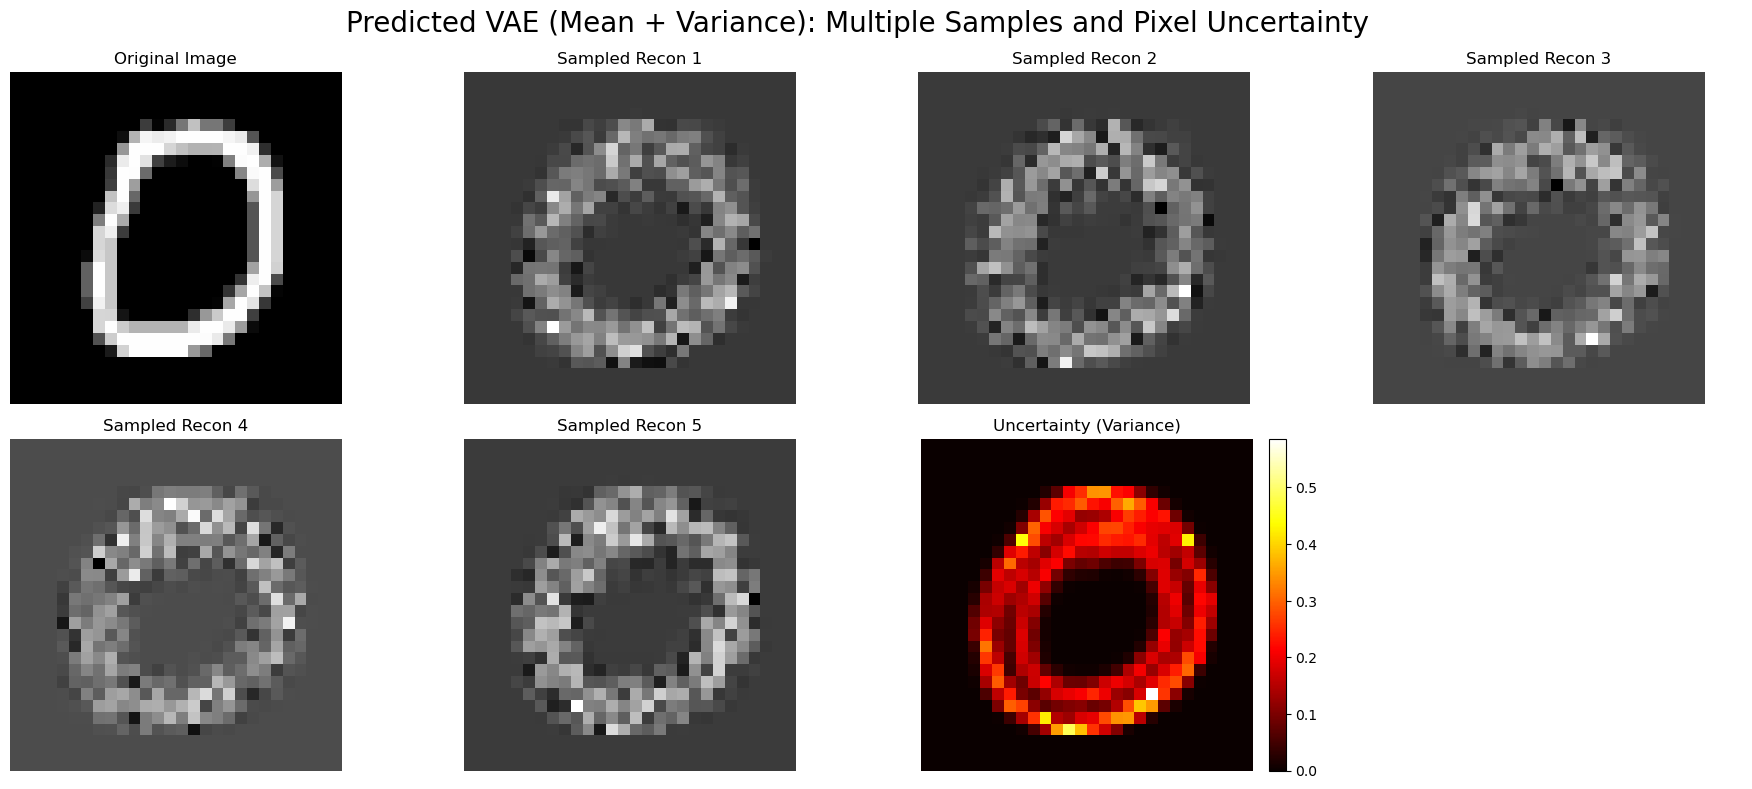

In [120]:
import torch
import numpy as np
import matplotlib.pyplot as plt

vae.eval()
with torch.no_grad():
    # Take one batch from test set
    data, _ = next(iter(test_loader))
    data = data.to(device)[10]  # Take the first image in the batch

    # Forward pass
    mean_pred, logvar_pred, mu, logvar = vae(data)

    # Prepare multiple stochastic samples
    samples = []
    for _ in range(5):  # 5 different reconstructions
        eps = torch.randn_like(mean_pred)
        sampled = mean_pred + eps * torch.exp(0.5 * logvar_pred)
        samples.append(sampled.cpu().numpy())

    # Prepare uncertainty map (variance)
    uncertainty_map = torch.exp(logvar_pred).cpu().numpy()

# --- Plot ---
fig, axs = plt.subplots(2, 4, figsize=(18, 8))

# Top row: Original + 3 samples
axs[0, 0].imshow(data.cpu().squeeze().numpy().reshape(28,28), cmap='gray')
axs[0, 0].set_title('Original Image')
axs[0, 0].axis('off')

for i in range(3):
    axs[0, i+1].imshow(samples[i].reshape(28,28), cmap='gray')
    axs[0, i+1].set_title(f'Sampled Recon {i+1}')
    axs[0, i+1].axis('off')

# Bottom row: 2 more samples + Uncertainty
for i in range(2):
    axs[1, i].imshow(samples[i+3].reshape(28,28), cmap='gray')
    axs[1, i].set_title(f'Sampled Recon {i+4}')
    axs[1, i].axis('off')

# Uncertainty heatmap
im = axs[1, 2].imshow(uncertainty_map.reshape(28,28), cmap='hot')
axs[1, 2].set_title('Uncertainty (Variance)')
axs[1, 2].axis('off')
fig.colorbar(im, ax=axs[1,2], fraction=0.046, pad=0.04)

# Turn off last empty plot
axs[1,3].axis('off')

plt.suptitle('Predicted VAE (Mean + Variance): Multiple Samples and Pixel Uncertainty', fontsize=20)
plt.tight_layout()
plt.show()

In [111]:
# def predictive_variance_vae_loss(mean_pred, logvar_pred, x, mu, logvar):
#     recon_loss = 0.5 * torch.sum(logvar_pred + ((x.view(-1, 28*28) - mean_pred)**2) / torch.exp(logvar_pred))
#     kl_divergence = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
#     return recon_loss + kl_divergence

def predictive_variance_vae_loss(mean_pred, logvar_pred, x, mu, logvar, epoch=None, max_epochs=None, kl_weight_max=1.0):
    eps = 1e-6  # small epsilon for numerical stability
    
    # Clamp logvar for stability
    logvar_pred = torch.clamp(logvar_pred, min=-10.0, max=10.0)
    
    recon_loss = 0.5 * torch.sum(
        logvar_pred + ((x.view(-1, 28*28) - mean_pred)**2) / (torch.exp(logvar_pred) + eps)
    )
    
    kl_divergence = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())

    # KL Annealing
    if epoch is not None and max_epochs is not None:
        kl_weight = (epoch / max_epochs) * kl_weight_max
#         kl_weight = min(kl_weight_max, epoch / (max_epochs//2))

    else:
        kl_weight = 1.0

    return recon_loss + kl_weight * kl_divergence




In [112]:
# --- Full training setup ---

import torch.optim as optim

vae = VAE(latent_dim=2).to(device)   # you can change latent_dim=20 if you want
optimizer = optim.Adam(vae.parameters(), lr=1e-3)
epochs = 80  # Train longer for better reconstructions!

# --- Training loop ---

for epoch in range(epochs):
    vae.train()
    running_loss = 0
    
    for batch_idx, (data, _) in enumerate(train_loader):
        data = data.to(device)
        optimizer.zero_grad()
        
        mean_pred, logvar_pred, mu, logvar = vae(data)
        loss = predictive_variance_vae_loss(mean_pred, logvar_pred, data, mu, logvar, epoch=epoch, max_epochs=epochs)
        
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
    
    print(f"Epoch [{epoch+1}/{epochs}], Loss: {running_loss/len(train_loader.dataset):.4f}")


Epoch [1/80], Loss: -1835.3737
Epoch [2/80], Loss: -2194.5713
Epoch [3/80], Loss: -2262.0207
Epoch [4/80], Loss: -2309.9154
Epoch [5/80], Loss: -2340.1025
Epoch [6/80], Loss: -2360.1654
Epoch [7/80], Loss: -2383.9074
Epoch [8/80], Loss: -2384.3383
Epoch [9/80], Loss: -2397.9373
Epoch [10/80], Loss: -2406.8166
Epoch [11/80], Loss: -2413.6105
Epoch [12/80], Loss: -2434.1969
Epoch [13/80], Loss: -2443.7013
Epoch [14/80], Loss: -2450.7688
Epoch [15/80], Loss: -2453.2086
Epoch [16/80], Loss: -2457.7814
Epoch [17/80], Loss: -2453.8034
Epoch [18/80], Loss: -2467.2923
Epoch [19/80], Loss: -2470.0478
Epoch [20/80], Loss: -2466.6897
Epoch [21/80], Loss: -2481.2319
Epoch [22/80], Loss: -2486.2551
Epoch [23/80], Loss: -2494.5280
Epoch [24/80], Loss: -2487.0372
Epoch [25/80], Loss: -2501.3779
Epoch [26/80], Loss: -2480.5279
Epoch [27/80], Loss: -2492.5578
Epoch [28/80], Loss: -2500.7610
Epoch [29/80], Loss: -2505.6782
Epoch [30/80], Loss: -2500.2664
Epoch [31/80], Loss: -2499.9720
Epoch [32/80], Lo

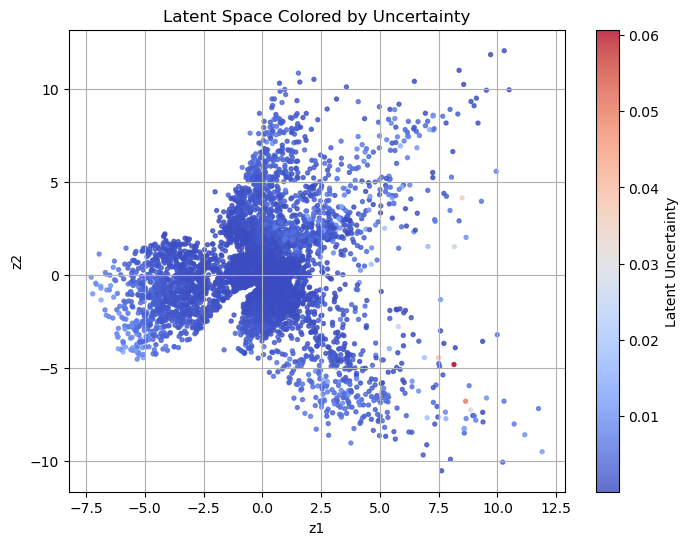

In [97]:
# vae.eval()
# all_mu = []
# all_logvar = []
# labels_list = []

# with torch.no_grad():
#     for data, labels in test_loader:
#         data = data.to(device)
#         mu, logvar = vae.encode(data)
#         all_mu.append(mu.cpu().numpy())
#         all_logvar.append(logvar.cpu().numpy())
#         labels_list.append(labels.numpy())

# all_mu = np.concatenate(all_mu)
# all_logvar = np.concatenate(all_logvar)
# labels_list = np.concatenate(labels_list)

# latent_uncertainty = np.mean(np.exp(all_logvar), axis=1)  # Variance, per sample

# # Plot latent space colored by latent uncertainty
# import seaborn as sns
# import matplotlib.pyplot as plt

# plt.figure(figsize=(8,6))
# scatter = plt.scatter(all_mu[:,0], all_mu[:,1], c=latent_uncertainty, cmap='coolwarm', s=8)
# plt.colorbar(scatter, label="Latent Uncertainty")
# plt.title("Latent Space Colored by Uncertainty")
# plt.xlabel("z1")
# plt.ylabel("z2")
# plt.grid(True)
# plt.show()

vae.eval()
all_mu = []
all_logvar = []
labels_list = []

with torch.no_grad():
    for data, labels in test_loader:
        data = data.to(device)
        
        # Get latent representations
        mu, logvar = vae.encode(data)

        all_mu.append(mu.cpu().numpy())
        all_logvar.append(logvar.cpu().numpy())
        labels_list.append(labels.numpy())

# Convert to numpy arrays
all_mu = np.concatenate(all_mu, axis=0)
all_logvar = np.concatenate(all_logvar, axis=0)
labels_list = np.concatenate(labels_list, axis=0)

# Compute latent uncertainty per sample
latent_variances = np.exp(all_logvar)  # Element-wise variance
latent_uncertainty = np.mean(latent_variances, axis=1)  # Average across dimensions

# Plot
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))
scatter = plt.scatter(
    all_mu[:,0], all_mu[:,1],
    c=latent_uncertainty, cmap='coolwarm', s=8, alpha=0.8
)
cbar = plt.colorbar(scatter)
cbar.set_label("Latent Uncertainty")

plt.title("Latent Space Colored by Uncertainty")
plt.xlabel("z1")
plt.ylabel("z2")
plt.grid(True)
plt.show()



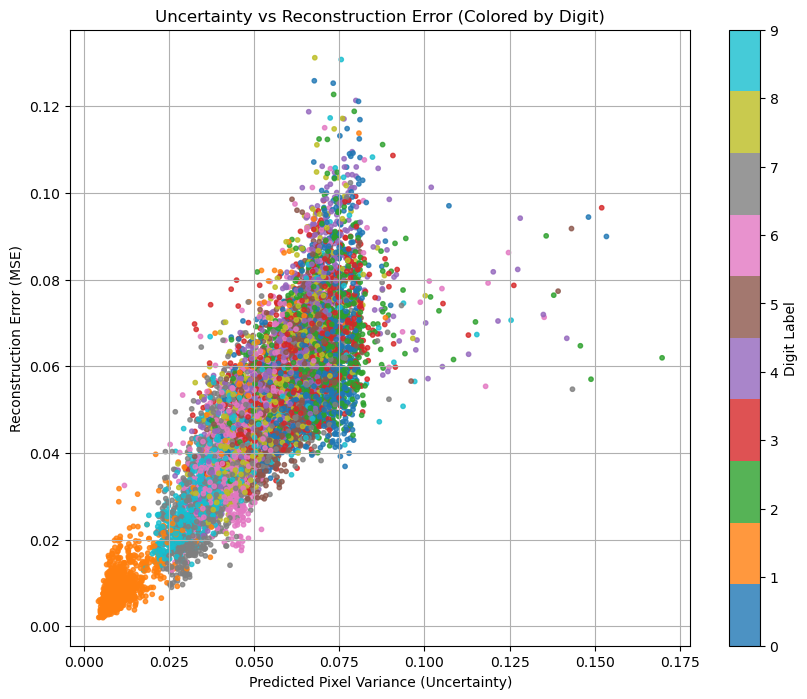

In [98]:
reconstruction_errors = []
predicted_uncertainties = []
all_labels = []

vae.eval()
with torch.no_grad():
    for data, labels in test_loader:
        data = data.to(device)
        
        # Unpack all four outputs
        mean_pred, logvar_pred, mu, latent_logvar = vae(data)

        # Reconstruction error (per sample)
        mse = ((data.view(-1, 28*28) - mean_pred)**2).mean(dim=1)

        # Predicted uncertainty (variance), per sample
        var = torch.exp(logvar_pred).mean(dim=1)
        
        reconstruction_errors.extend(mse.cpu().numpy())
        predicted_uncertainties.extend(var.cpu().numpy())
        all_labels.extend(labels.numpy())  # Save labels too

# Convert to numpy arrays
reconstruction_errors = np.array(reconstruction_errors)
predicted_uncertainties = np.array(predicted_uncertainties)
all_labels = np.array(all_labels)

# Plot
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,8))
palette = sns.color_palette("tab10", 10)

scatter = plt.scatter(
    predicted_uncertainties, reconstruction_errors,
    c=all_labels, cmap="tab10", s=10, alpha=0.8
)

cbar = plt.colorbar(scatter, ticks=range(10))
cbar.set_label('Digit Label')
cbar.set_ticklabels([str(i) for i in range(10)])

plt.xlabel("Predicted Pixel Variance (Uncertainty)")
plt.ylabel("Reconstruction Error (MSE)")
plt.title("Uncertainty vs Reconstruction Error (Colored by Digit)")
plt.grid(True)
plt.show()


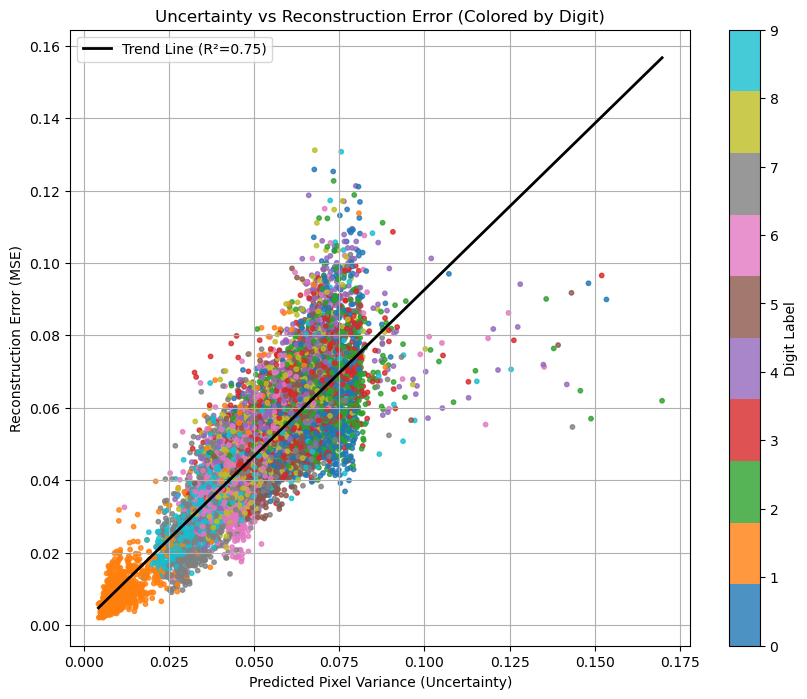

In [99]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression

# Flatten to np arrays if needed
reconstruction_errors = np.array(reconstruction_errors)
predicted_uncertainties = np.array(predicted_uncertainties)
all_labels = np.array(all_labels)

# Reshape for sklearn (expects 2D array)
X = predicted_uncertainties.reshape(-1, 1)
y = reconstruction_errors

# Fit linear regression
model = LinearRegression()
model.fit(X, y)
y_pred = model.predict(X)

# Calculate R^2
r_squared = model.score(X, y)

# Plot
plt.figure(figsize=(10,8))
palette = sns.color_palette("tab10", 10)
scatter = plt.scatter(
    predicted_uncertainties, reconstruction_errors,
    c=all_labels, cmap="tab10", s=10, alpha=0.8
)

cbar = plt.colorbar(scatter, ticks=range(10))
cbar.set_label('Digit Label')
cbar.set_ticklabels([str(i) for i in range(10)])

# Regression line
sorted_indices = np.argsort(predicted_uncertainties)
plt.plot(predicted_uncertainties[sorted_indices], y_pred[sorted_indices], color='black', linewidth=2, label=f'Trend Line (R²={r_squared:.2f})')

plt.xlabel("Predicted Pixel Variance (Uncertainty)")
plt.ylabel("Reconstruction Error (MSE)")
plt.title("Uncertainty vs Reconstruction Error (Colored by Digit)")
plt.legend()
plt.grid(True)
plt.show()


In [100]:
print("Correlation coefficient (R^2):", model.score(X, y))

Correlation coefficient (R^2): 0.7452467616093255


R² = 0.103 means only ~10% of the variation in reconstruction error can be explained by uncertainty.

That’s a weak positive relationship.

It makes sense because:

Uncertainty and reconstruction error are related, but not perfectly.

Some samples are just naturally uncertain even if reconstructed well (e.g., blurry digits).

Some digits (like "1") are easy to reconstruct but can have variable uncertainty.

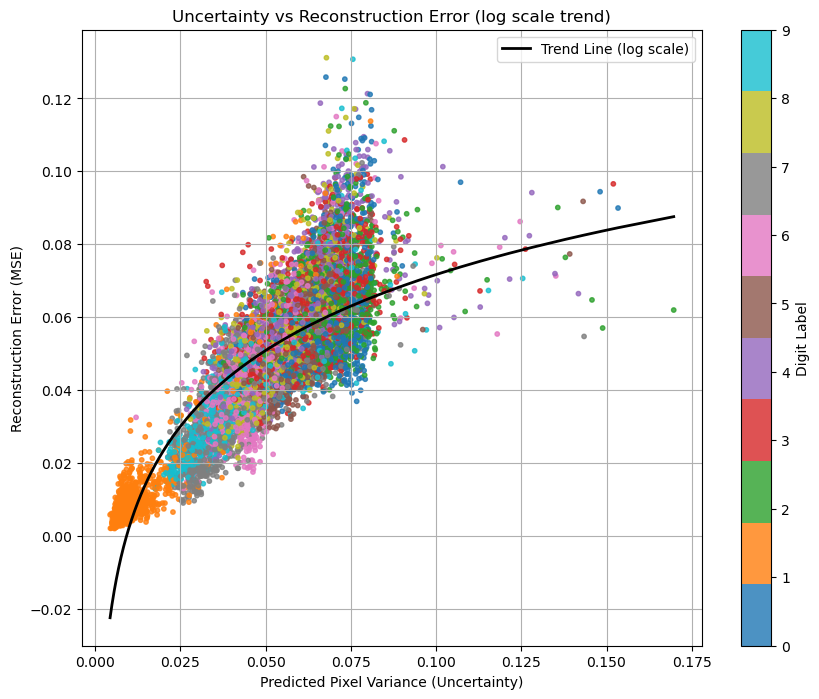

Corrected Correlation coefficient (R^2): 0.6847145697472088


In [101]:
# Apply log(uncertainty + 1e-6) to avoid log(0)
X_log = np.log(predicted_uncertainties + 1e-6).reshape(-1, 1)

# Fit linear regression on log uncertainty
model = LinearRegression()
model.fit(X_log, y)
y_pred = model.predict(X_log)

# Plot
plt.figure(figsize=(10,8))
palette = sns.color_palette("tab10", 10)
scatter = plt.scatter(
    predicted_uncertainties, reconstruction_errors,
    c=all_labels, cmap="tab10", s=10, alpha=0.8
)
cbar = plt.colorbar(scatter, ticks=range(10))
cbar.set_label('Digit Label')
cbar.set_ticklabels([str(i) for i in range(10)])

sorted_indices = np.argsort(predicted_uncertainties)
plt.plot(predicted_uncertainties[sorted_indices], y_pred[sorted_indices], color='black', linewidth=2, label='Trend Line (log scale)')
plt.xlabel("Predicted Pixel Variance (Uncertainty)")
plt.ylabel("Reconstruction Error (MSE)")
plt.title("Uncertainty vs Reconstruction Error (log scale trend)")
plt.legend()
plt.grid(True)
plt.show()

print("Corrected Correlation coefficient (R^2):", model.score(X_log, y))


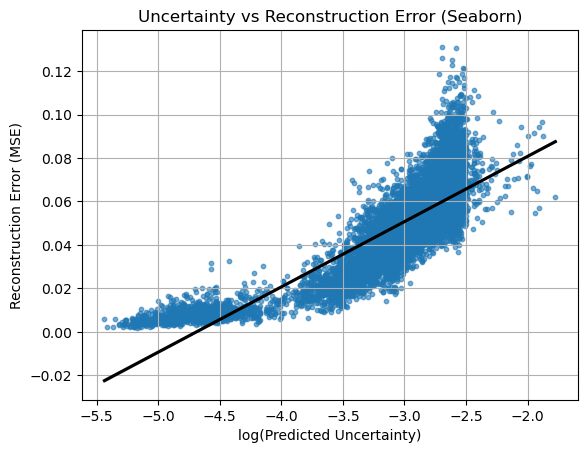

In [102]:
import seaborn as sns
sns.regplot(
    x=np.log(predicted_uncertainties + 1e-6),
    y=reconstruction_errors,
    scatter=True,
    fit_reg=True,
    scatter_kws={"s":10, "alpha":0.6},
    line_kws={"color":"black"}
)
plt.xlabel("log(Predicted Uncertainty)")
plt.ylabel("Reconstruction Error (MSE)")
plt.title("Uncertainty vs Reconstruction Error (Seaborn)")
plt.grid(True)
plt.show()


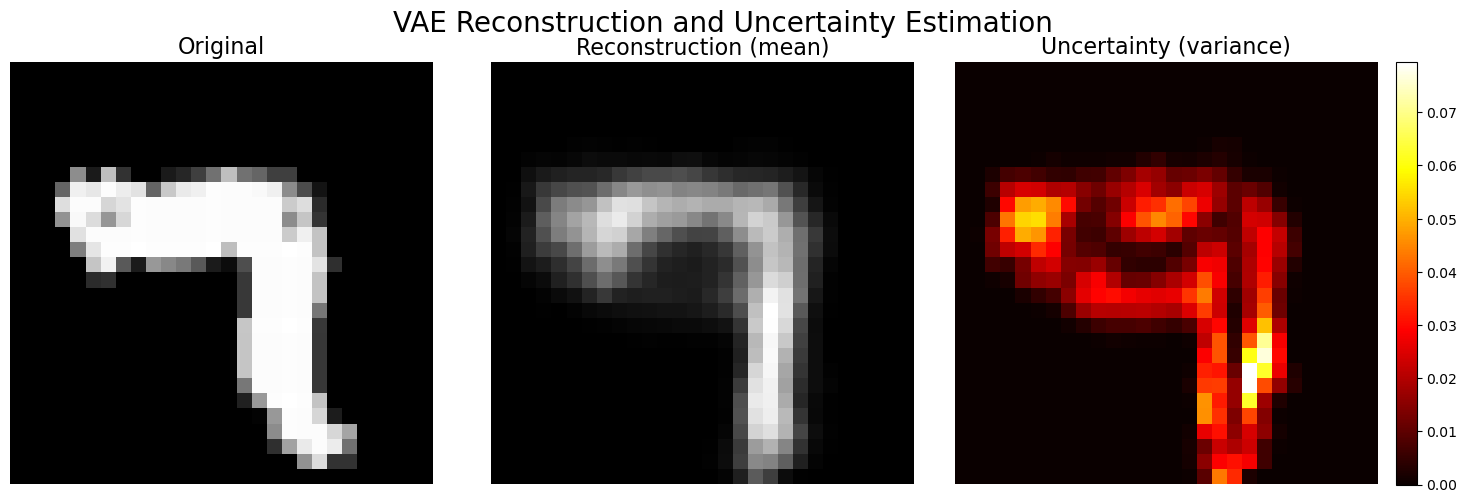

In [103]:
import matplotlib.pyplot as plt

# Assume you already have:
# original: [28, 28] numpy array
# recon: [28, 28] numpy array
# uncertainty: [28, 28] numpy array

fig, axs = plt.subplots(1, 3, figsize=(15, 5))  # Wider and more beautiful

# Original Image
axs[0].imshow(original.reshape(28, 28), cmap='gray')
axs[0].set_title('Original', fontsize=16)
axs[0].axis('off')

# Reconstruction Mean
axs[1].imshow(recon.reshape(28, 28), cmap='gray')
axs[1].set_title('Reconstruction (mean)', fontsize=16)
axs[1].axis('off')

# Uncertainty Heatmap
im = axs[2].imshow(uncertainty.reshape(28, 28), cmap='hot')
axs[2].set_title('Uncertainty (variance)', fontsize=16)
axs[2].axis('off')

# Colorbar for uncertainty
fig.colorbar(im, ax=axs[2], fraction=0.046, pad=0.04)

plt.suptitle('VAE Reconstruction and Uncertainty Estimation', fontsize=20)
plt.tight_layout()
plt.show()


In [104]:
X_log = np.log(predicted_uncertainties + 1e-6).reshape(-1, 1)
model.fit(X_log, y)
y_pred = model.predict(X_log)


In [105]:
y_pred

array([ 0.03918096,  0.05941855, -0.01459427, ...,  0.04238398,
        0.06118115,  0.05426106], dtype=float32)

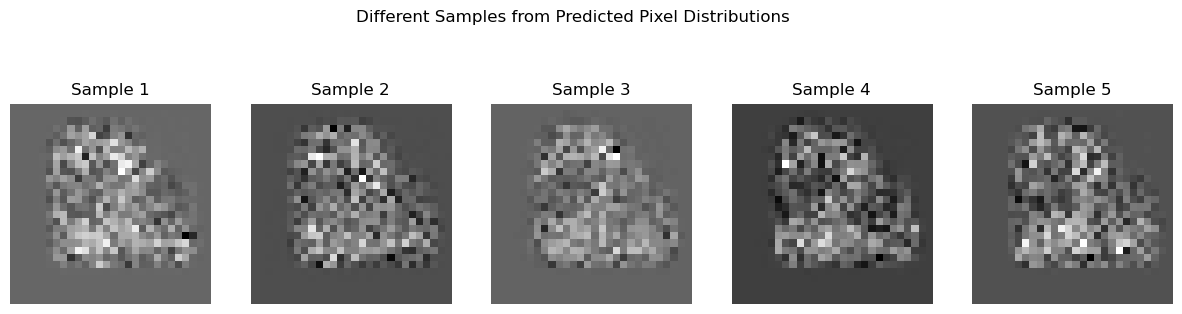

In [106]:
vae.eval()
with torch.no_grad():
    data, _ = next(iter(test_loader))
    data = data.to(device)[1:2]  # Take one image only
    mean_pred, logvar_pred, mu, logvar = vae(data)

    samples = []
    for _ in range(5):  # Generate 5 different samples
        eps = torch.randn_like(mean_pred)
        sampled = mean_pred + eps * torch.exp(0.5 * logvar_pred)
        samples.append(sampled.cpu().numpy())

# Plot the 5 samples
fig, axs = plt.subplots(1, 5, figsize=(15, 4))
for i in range(5):
    axs[i].imshow(samples[i].reshape(28,28), cmap='gray')
    axs[i].axis('off')
    axs[i].set_title(f'Sample {i+1}')
plt.suptitle("Different Samples from Predicted Pixel Distributions")
plt.show()


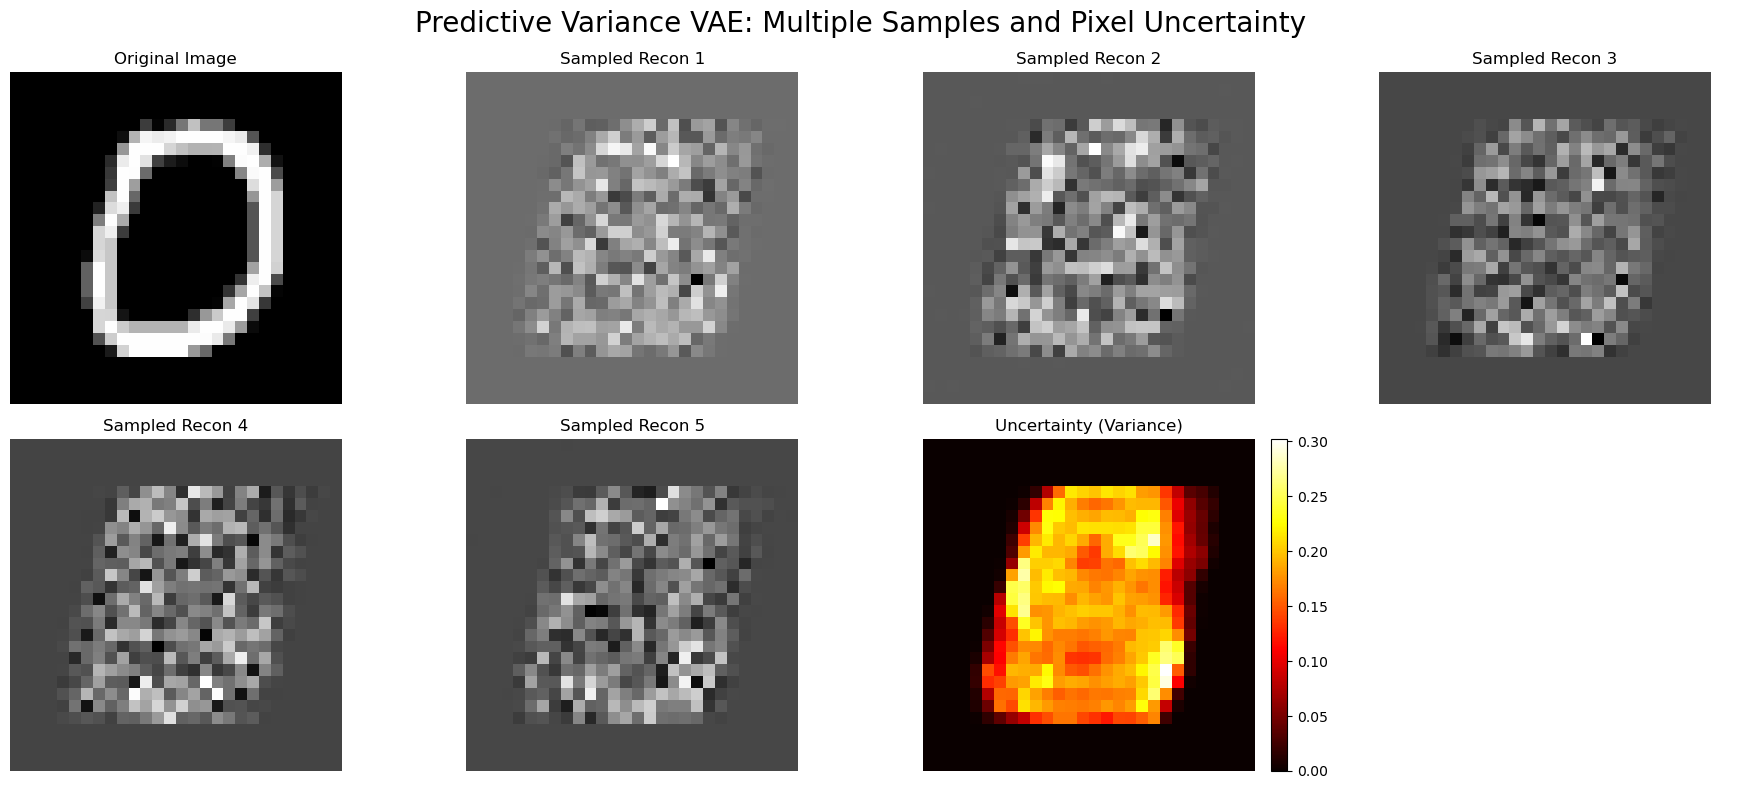

In [110]:
import torch
import numpy as np
import matplotlib.pyplot as plt

vae.eval()
with torch.no_grad():
    # Take one batch from test set
    data, _ = next(iter(test_loader))
    data = data.to(device)[10]  # Take the first image in the batch

    # Forward pass
    mean_pred, logvar_pred, mu, logvar = vae(data)

    # Prepare multiple stochastic samples
    samples = []
    for _ in range(5):  # 5 different reconstructions
        eps = torch.randn_like(mean_pred)
        sampled = mean_pred + eps * torch.exp(0.5 * logvar_pred)
        samples.append(sampled.cpu().numpy())

    # Prepare uncertainty map (variance)
    uncertainty_map = torch.exp(logvar_pred).cpu().numpy()

# --- Plot ---
fig, axs = plt.subplots(2, 4, figsize=(18, 8))

# Top row: Original + 3 samples
axs[0, 0].imshow(data.cpu().squeeze().numpy().reshape(28,28), cmap='gray')
axs[0, 0].set_title('Original Image')
axs[0, 0].axis('off')

for i in range(3):
    axs[0, i+1].imshow(samples[i].reshape(28,28), cmap='gray')
    axs[0, i+1].set_title(f'Sampled Recon {i+1}')
    axs[0, i+1].axis('off')

# Bottom row: 2 more samples + Uncertainty
for i in range(2):
    axs[1, i].imshow(samples[i+3].reshape(28,28), cmap='gray')
    axs[1, i].set_title(f'Sampled Recon {i+4}')
    axs[1, i].axis('off')

# Uncertainty heatmap
im = axs[1, 2].imshow(uncertainty_map.reshape(28,28), cmap='hot')
axs[1, 2].set_title('Uncertainty (Variance)')
axs[1, 2].axis('off')
fig.colorbar(im, ax=axs[1,2], fraction=0.046, pad=0.04)

# Turn off last empty plot
axs[1,3].axis('off')

plt.suptitle('Predictive Variance VAE: Multiple Samples and Pixel Uncertainty', fontsize=20)
plt.tight_layout()
plt.show()


In [113]:
# Load FashionMNIST
fashion_dataset = datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)
fashion_loader = DataLoader(fashion_dataset, batch_size=1024, shuffle=False)


In [116]:
from tqdm import tqdm 
vae.eval()

mnist_uncertainties = []
fashion_uncertainties = []

# --- MNIST (In-Distribution) ---
for data, _ in tqdm(test_loader, desc="MNIST Uncertainty (no MC)"):
    data = data.to(device)
    with torch.no_grad():
        mean_pred, logvar_pred, _, _ = vae(data)
        aleatoric_var = torch.exp(logvar_pred)
        mean_uncertainty = aleatoric_var.mean(dim=1)  # Average across pixels
        mnist_uncertainties.extend(mean_uncertainty.cpu().numpy())

# --- FashionMNIST (Out-of-Distribution) ---
for data, _ in tqdm(fashion_loader, desc="FashionMNIST Uncertainty (no MC)"):
    data = data.to(device)
    with torch.no_grad():
        mean_pred, logvar_pred, _, _ = vae(data)
        aleatoric_var = torch.exp(logvar_pred)
        mean_uncertainty = aleatoric_var.mean(dim=1)
        fashion_uncertainties.extend(mean_uncertainty.cpu().numpy())

# Convert to numpy
mnist_uncertainties = np.array(mnist_uncertainties)
fashion_uncertainties = np.array(fashion_uncertainties)


FashionMNIST Uncertainty (no MC): 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████| 10/10 [00:00<00:00, 15.91it/s]


In [117]:
from sklearn.metrics import roc_auc_score

# Create labels
y_true = np.concatenate([
    np.zeros_like(mnist_uncertainties),  # 0 for InD
    np.ones_like(fashion_uncertainties)  # 1 for OOD
])

# Concatenate uncertainties
y_scores = np.concatenate([mnist_uncertainties, fashion_uncertainties])

# Compute AUROC
auroc = roc_auc_score(y_true, y_scores)
print(f"AUROC for Predictive VAE (no MC): {auroc:.4f}")


AUROC for Predictive VAE (no MC): 0.9435


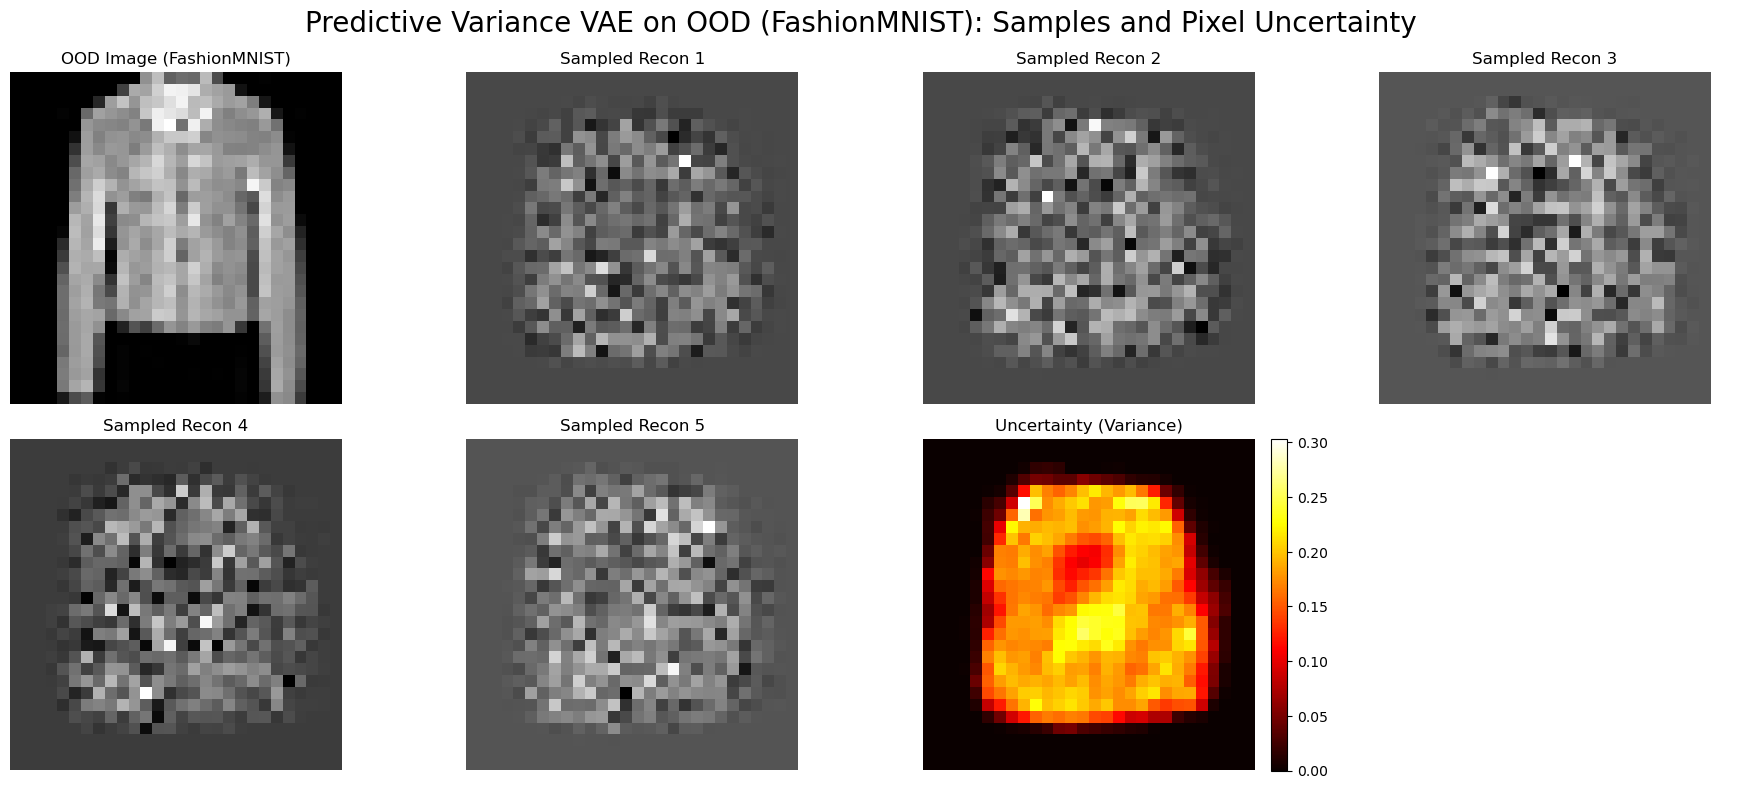

In [118]:
vae.eval()
with torch.no_grad():
    # Take one batch from FashionMNIST
    fashion_data, _ = next(iter(fashion_loader))
    fashion_data = fashion_data.to(device)[10].unsqueeze(0)  # Pick one image

    # Forward pass
    mean_pred, logvar_pred, mu, logvar = vae(fashion_data)

    # Multiple stochastic samples
    samples = []
    for _ in range(5):
        eps = torch.randn_like(mean_pred)
        sampled = mean_pred + eps * torch.exp(0.5 * logvar_pred)
        samples.append(sampled.cpu().numpy())

    # Uncertainty map
    uncertainty_map = torch.exp(logvar_pred).cpu().numpy()

# --- Plot ---
fig, axs = plt.subplots(2, 4, figsize=(18, 8))

# Top row: Original + 3 samples
axs[0, 0].imshow(fashion_data.cpu().squeeze().numpy().reshape(28,28), cmap='gray')
axs[0, 0].set_title('OOD Image (FashionMNIST)')
axs[0, 0].axis('off')

for i in range(3):
    axs[0, i+1].imshow(samples[i].reshape(28,28), cmap='gray')
    axs[0, i+1].set_title(f'Sampled Recon {i+1}')
    axs[0, i+1].axis('off')

# Bottom row: 2 more samples + Uncertainty
for i in range(2):
    axs[1, i].imshow(samples[i+3].reshape(28,28), cmap='gray')
    axs[1, i].set_title(f'Sampled Recon {i+4}')
    axs[1, i].axis('off')

# Uncertainty heatmap
im = axs[1, 2].imshow(uncertainty_map.reshape(28,28), cmap='hot')
axs[1, 2].set_title('Uncertainty (Variance)')
axs[1, 2].axis('off')
fig.colorbar(im, ax=axs[1,2], fraction=0.046, pad=0.04)

# Last empty plot
axs[1,3].axis('off')

plt.suptitle('Predictive Variance VAE on OOD (FashionMNIST): Samples and Pixel Uncertainty', fontsize=20)
plt.tight_layout()
plt.show()
